# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
from sklearn import preprocessing
import statsmodels.api as sm
import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Setting the directory for data

In [2]:
dir("/Users/ljunodrstat/CStat2026_project/")
os.listdir()

['SalePrice_LogSalePrice.png',
 'CP_project_midterm_presentation.pptx',
 '.DS_Store',
 'report.md',
 'project_STUDENTID_processed.ipynb.zip',
 'Capture d’écran 2026-04-19 à 17.21.22.png',
 'Anova2.png',
 't_distribution_SalePriceMean180000.png',
 'README.md',
 'my_plot_skewed.png',
 'project_STUDENTID.ipynb',
 'Capture d’écran 2026-04-19 à 17.24.26.png',
 '.ipynb_checkpoints',
 '.jupyter',
 '.git',
 'Data',
 'project_STUDENTID_processed.ipynb']

---
## Load Data

In [3]:
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


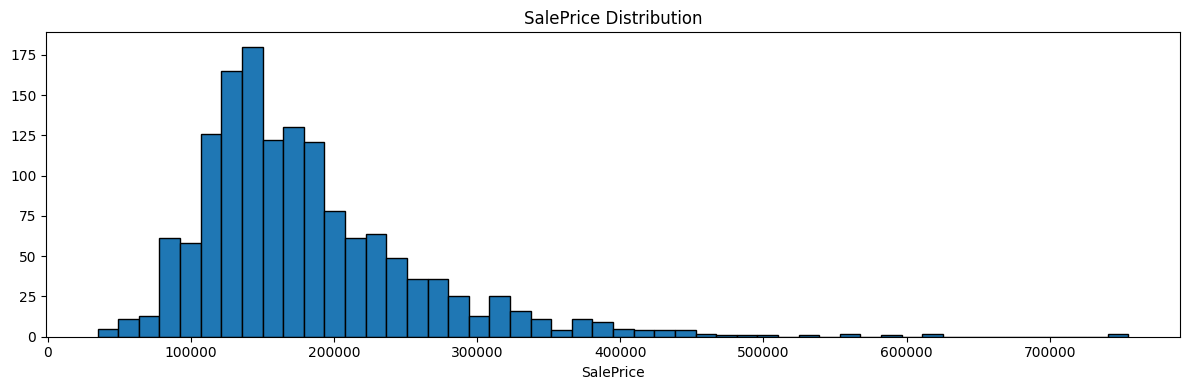

Skewness: 1.883


In [4]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

A log transformation can bring a normal distribution

---
## Cleaning the data
Are there any NA values in the variables of interest for the project? If yes, how to replace them?

In [5]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]

features_dt = train[features].copy()
print(f"{features_dt.head()}\n")

print("How many rows have missing values:")
print(features_dt[features_dt.isna().any(axis=1)].shape)

   OverallQual ExterQual BsmtQual KitchenQual FireplaceQu CentralAir LotShape  \
0            7        Gd       Gd          Gd         NaN          Y      Reg   
1            6        TA       Gd          TA          TA          Y      Reg   
2            7        Gd       Gd          Gd          TA          Y      IR1   
3            7        TA       TA          Gd          Gd          Y      IR1   
4            8        Gd       Gd          Gd          TA          Y      IR1   

  LandSlope  MoSold  YrSold  
0       Gtl       2    2008  
1       Gtl       5    2007  
2       Gtl       9    2008  
3       Gtl       2    2006  
4       Gtl      12    2008  

How many rows have missing values:
(699, 10)


In [6]:
for col in features_dt.columns:
    print(f"Distinct values in {col}: {features_dt[col].unique()}")

Distinct values in OverallQual: [ 7  6  8  5  9  4 10  3  1  2]
Distinct values in ExterQual: ['Gd' 'TA' 'Ex' 'Fa']
Distinct values in BsmtQual: ['Gd' 'TA' 'Ex' nan 'Fa']
Distinct values in KitchenQual: ['Gd' 'TA' 'Ex' 'Fa']
Distinct values in FireplaceQu: [nan 'TA' 'Gd' 'Fa' 'Ex' 'Po']
Distinct values in CentralAir: ['Y' 'N']
Distinct values in LotShape: ['Reg' 'IR1' 'IR2' 'IR3']
Distinct values in LandSlope: ['Gtl' 'Mod' 'Sev']
Distinct values in MoSold: [ 2  5  9 12 10  8 11  4  1  7  3  6]
Distinct values in YrSold: [2008 2007 2006 2009 2010]


## NaN Values 
We observe nan values in two variables: "BsmtQual" and "FireplaceQu", which means the feature is absent, according to the data description file.

**Solution**<br>
We replace them with None for clarity purpose.

## Ordinal Values
6 variables ("ExterQual", "BsmtQual", "KitchenQual", "FireplaceQu", "LotShape", "LandSlope") are ordinal values, ranking quality intp different levels (4 ranks in general, 3 for the "LandSlope").

**Solution**<br>
Unlike "OverallQual", which is already numeric, we need to correct them by adding a rank, using a dictionnary. 

In [7]:
features_dt['BsmtQual'] = features_dt['BsmtQual'].fillna('No_Basement')
features_dt['FireplaceQu'] = features_dt['FireplaceQu'].fillna('No_Fireplace')

print(features_dt['FireplaceQu'].unique())
print(features_dt['BsmtQual'].unique())

['No_Fireplace' 'TA' 'Gd' 'Fa' 'Ex' 'Po']
['Gd' 'TA' 'Ex' 'No_Basement' 'Fa']


## Dictionaries

In [8]:
qual_dict = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0,
    'No_Basement': 0,
    'No_Fireplace': 0,
    'No_Kitchen': 0
}

slope_dict = {
    'Gtl': 3,
    'Mod': 2,
    'Sev': 1,   
    'NA': 0
}

lotshape_dict = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1,
    'NA': 0
}
central_air_dict = {
    'Y': 1,
    'N': 0
}
train['ExterQual'] = train['ExterQual'].map(qual_dict)
test['ExterQual'] = test['ExterQual'].map(qual_dict)
train['BsmtQual'] = train['BsmtQual'].map(qual_dict)
test['BsmtQual'] = test['BsmtQual'].map(qual_dict)
train['KitchenQual'] = train['KitchenQual'].map(qual_dict)
test['KitchenQual'] = test['KitchenQual'].map(qual_dict)
train['FireplaceQu'] = train['FireplaceQu'].map(qual_dict)
test['FireplaceQu'] = test['FireplaceQu'].map(qual_dict)

train['LotShape'] = train['LotShape'].map(lotshape_dict)
test['LotShape'] = test['LotShape'].map(lotshape_dict)
train['LandSlope'] = train['LandSlope'].map(slope_dict)
test['LandSlope'] = test['LandSlope'].map(slope_dict)
train['CentralAir'] = train['CentralAir'].map(central_air_dict)
test['CentralAir'] = test['CentralAir'].map(central_air_dict)

print(f"{train.head()}\n")
print(train.isna().sum())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley  LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN         4   
1   2          20       RL         80.0     9600   Pave   NaN         4   
2   3          60       RL         68.0    11250   Pave   NaN         3   
3   4          70       RL         60.0     9550   Pave   NaN         3   
4   5          60       RL         84.0    14260   Pave   NaN         3   

  LandContour Utilities LotConfig  LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside          3      CollgCr       Norm   
1         Lvl    AllPub       FR2          3      Veenker      Feedr   
2         Lvl    AllPub    Inside          3      CollgCr       Norm   
3         Lvl    AllPub    Corner          3      Crawfor       Norm   
4         Lvl    AllPub       FR2          3      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Story           

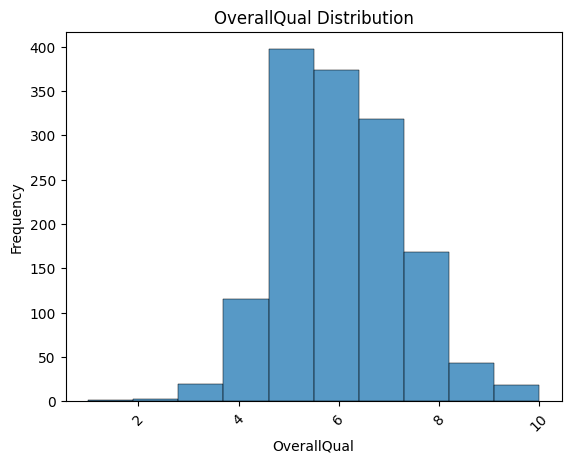

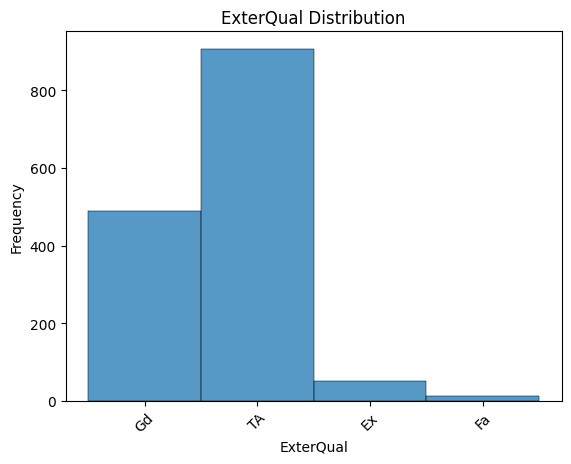

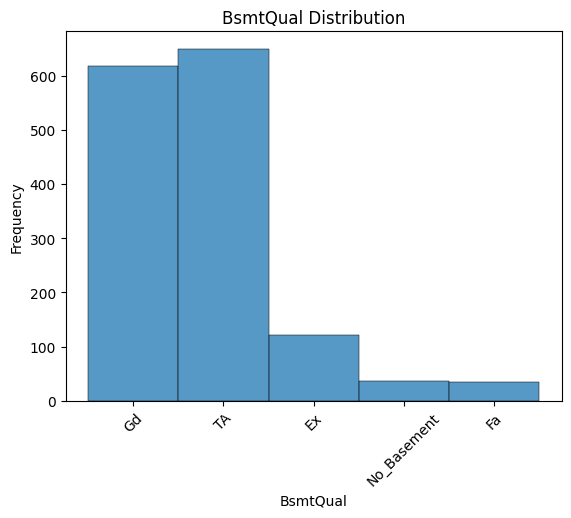

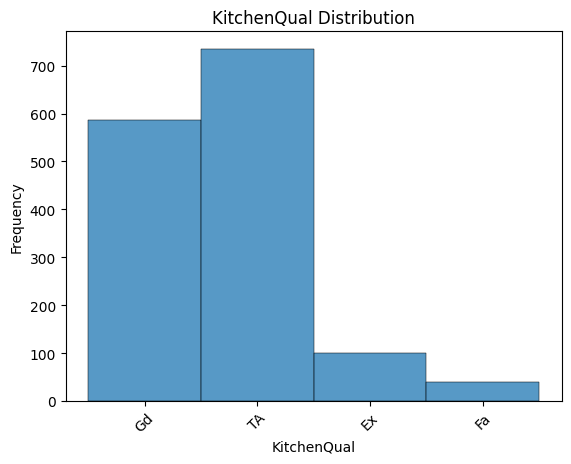

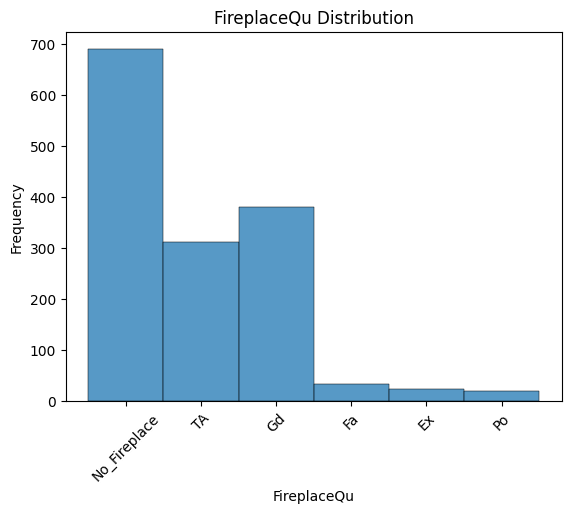

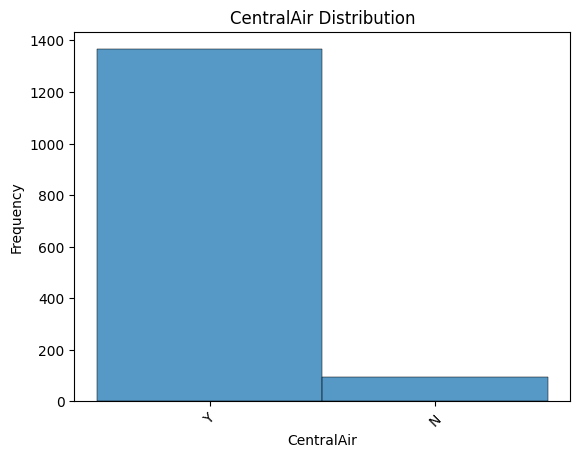

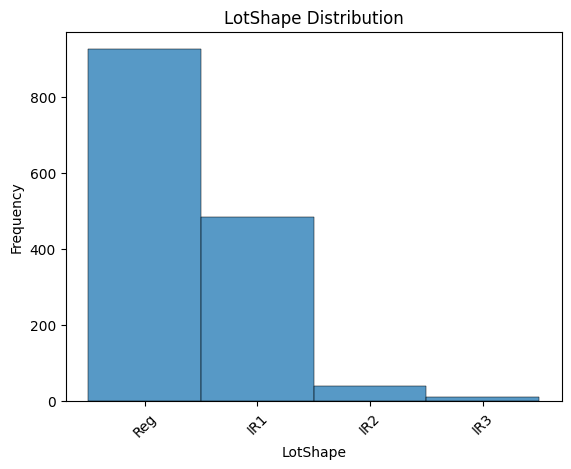

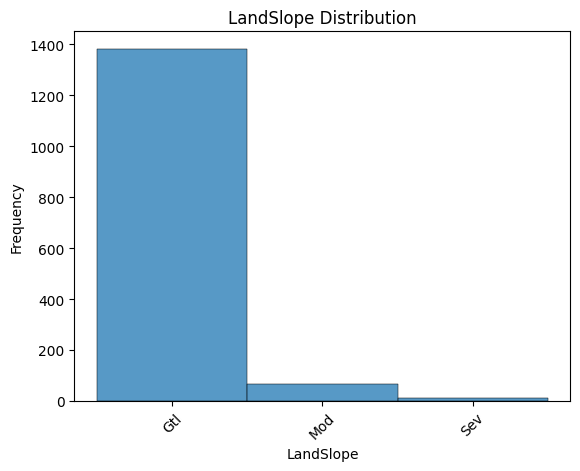

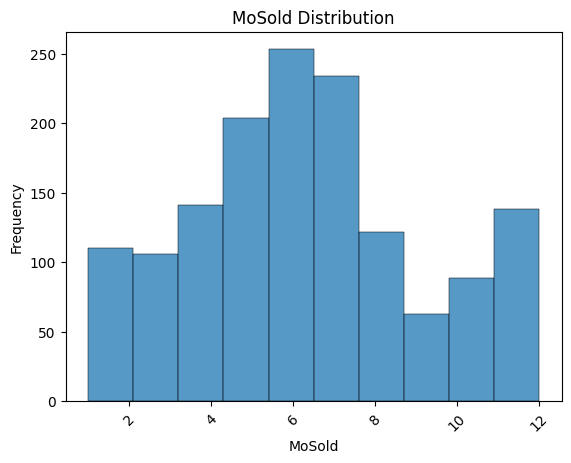

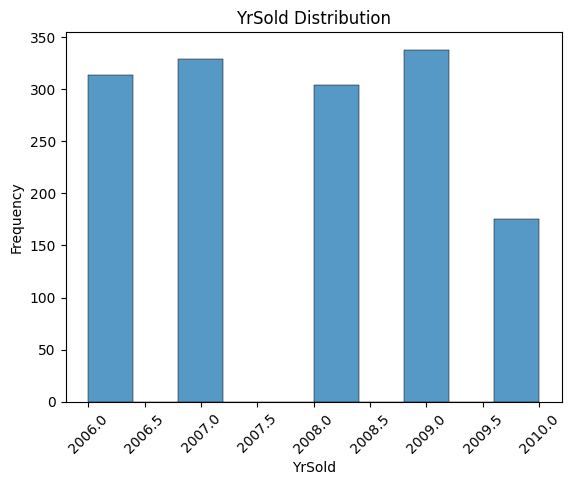

In [9]:
for col in features_dt.columns:
    sns.histplot(features_dt[col], kde=False, bins=10, edgecolor='black', linewidth=0.35)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

The corrections are valid - we now apply the same encoding to the train dataframe.

In [10]:
# Same encoding for the train dataframe

---
## Part 1: Classical Statistical Inference



Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

Sample Mean and Variance of SalePrice and key features


In [11]:
train['LogSalePrice'] = np.log(train['SalePrice'])

mean_LogSalePrice = train['LogSalePrice'].mean()
median_LogSalePrice = train['LogSalePrice'].median()
std_LogSalePrice = train['LogSalePrice'].std()
print(f'Mean: {mean_LogSalePrice:.2f}')
print(f'Median: {median_LogSalePrice:.2f}')
print(f'Standard Deviation: {std_LogSalePrice:.2f}')

Mean: 12.02
Median: 12.00
Standard Deviation: 0.40


In [12]:
mean_SalePrice = train['SalePrice'].mean()
median_SalePrice = train['SalePrice'].median()
std_SalePrice = train['SalePrice'].std()
print(f'Mean: {mean_SalePrice:.2f}')
print(f'Median: {median_SalePrice:.2f}')
print(f'Standard Deviation: {std_SalePrice:.2f}')

Mean: 180921.20
Median: 163000.00
Standard Deviation: 79442.50


### Feature classification by type

In [13]:
ordinal_mappings = {
    'ExterQual' : qual_dict,
    'BsmtQual' : qual_dict,
    'KitchenQual' : qual_dict,
    'FireplaceQu' : qual_dict,
    'LotShape' : lotshape_dict,
    'LandSlope' : slope_dict
}


def describe_features(df, feature, ordinal_mappings=None):
    if ordinal_mappings:
        mapped = df[feature].map(ordinal_mappings)
        valid = mapped.dropna()

        print(f"\n{feature} (ordinal ):")
        print(f"  Uniques values : {df[feature].unique()}")
        print(f" Distribution:\n{valid.value_counts().sort_index()}")
        print(f"  Mean: {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Missing values: {df[feature].isna().sum()}")
    elif pd.api.types.is_numeric_dtype(df[feature]):
        valid = df[feature].dropna()
        print(f"\n{feature} (numerical):")
        print(f" Mean : {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Q1 : {valid.quantile(0.25)}, Q3: {valid.quantile(0.75)}")
        print(f" Missing values: {df[feature].isna().sum()}")
    else: 
        print(f"\n{feature} (categorical):")
        print(f" Unique values: {df[feature].unique()}")
        print(f" Top values :\n {df[feature].nunique()}")
        print(f" Missing values: {df[feature].isna().sum()}")

In [14]:
features_ordinal = train[['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 'LotShape', 'LandSlope']]
features_numerical = train[['SalePrice', 'OverallQual', 'MoSold', 'YrSold']]


In [15]:
print("==== Target : Numerical variables =====")
for feat in features_numerical.columns:
    describe_features(train, feat)

==== Target : Numerical variables =====

SalePrice (numerical):
 Mean : 180921.20, Median: 163000.00, Std Dev: 79442.50
 Min-Max : 34900 - 755000
 Q1 : 129975.0, Q3: 214000.0
 Missing values: 0

OverallQual (numerical):
 Mean : 6.10, Median: 6.00, Std Dev: 1.38
 Min-Max : 1 - 10
 Q1 : 5.0, Q3: 7.0
 Missing values: 0

MoSold (numerical):
 Mean : 6.32, Median: 6.00, Std Dev: 2.70
 Min-Max : 1 - 12
 Q1 : 5.0, Q3: 8.0
 Missing values: 0

YrSold (numerical):
 Mean : 2007.82, Median: 2008.00, Std Dev: 1.33
 Min-Max : 2006 - 2010
 Q1 : 2007.0, Q3: 2009.0
 Missing values: 0


In [16]:
features_ordinal.head()

,ExterQual,BsmtQual,KitchenQual,FireplaceQu,LotShape,LandSlope
0,4,4.0,4,NaN,4,3
1,3,4.0,3,3.0,4,3
2,4,4.0,4,3.0,3,3
3,3,3.0,4,4.0,3,3
4,4,4.0,4,3.0,3,3


In [17]:
print("\n=== Ordinal features ==== ")
for feat in features_ordinal.columns:
        describe_features(train, feat)


=== Ordinal features ==== 

ExterQual (numerical):
 Mean : 3.40, Median: 3.00, Std Dev: 0.57
 Min-Max : 2 - 5
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

BsmtQual (numerical):
 Mean : 3.58, Median: 4.00, Std Dev: 0.68
 Min-Max : 2.0 - 5.0
 Q1 : 3.0, Q3: 4.0
 Missing values: 37

KitchenQual (numerical):
 Mean : 3.51, Median: 3.00, Std Dev: 0.66
 Min-Max : 2 - 5
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

FireplaceQu (numerical):
 Mean : 3.46, Median: 4.00, Std Dev: 0.74
 Min-Max : 1.0 - 5.0
 Q1 : 3.0, Q3: 4.0
 Missing values: 690

LotShape (numerical):
 Mean : 3.59, Median: 4.00, Std Dev: 0.58
 Min-Max : 1 - 4
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

LandSlope (numerical):
 Mean : 2.94, Median: 3.00, Std Dev: 0.28
 Min-Max : 1 - 3
 Q1 : 3.0, Q3: 3.0
 Missing values: 0


## Confidence intervals 
### for the mean SalePrice

In [18]:
mean_SalePrice = train['SalePrice'].mean()
std_SalePrice = train['SalePrice'].std()
n = len(train)
stat_err = stats.sem(train['SalePrice'], nan_policy='omit')
confidence = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence, degrees_freedom, loc=mean_SalePrice, scale=stat_err)

print(f"95% Confidence Interval for SalePrice: {confidence_interval[0]:.2f} to {confidence_interval[1]:.2f}")

95% Confidence Interval for SalePrice: 176842.84 to 184999.55


In [19]:
mean_LogSalePrice = train['LogSalePrice'].mean()
std_LogSalePrice = train['LogSalePrice'].std()
n_log = len(train)
stat_err_log = stats.sem(train['LogSalePrice'], nan_policy='omit')
confidence = 0.95
degrees_freedom = n_log - 1
confidence_interval_log = stats.t.interval(confidence, degrees_freedom, loc=mean_LogSalePrice, scale=stat_err_log)

print(f"95% Confidence Interval for LogSalePrice: {confidence_interval_log[0]:.2f} to {confidence_interval_log[1]:.2f}")

95% Confidence Interval for LogSalePrice: 12.00 to 12.04


<Axes: xlabel='LogSalePrice', ylabel='Count'>

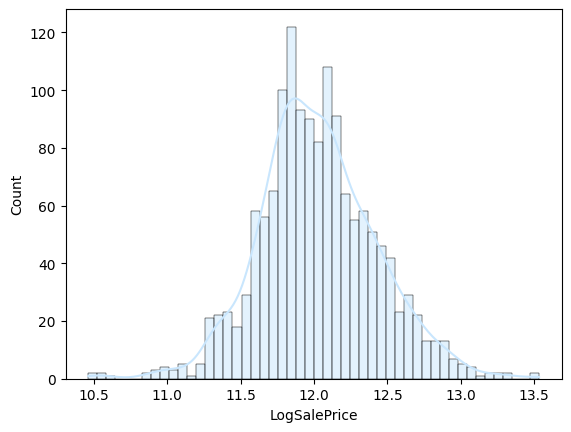

In [20]:
sns.histplot(train['LogSalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)

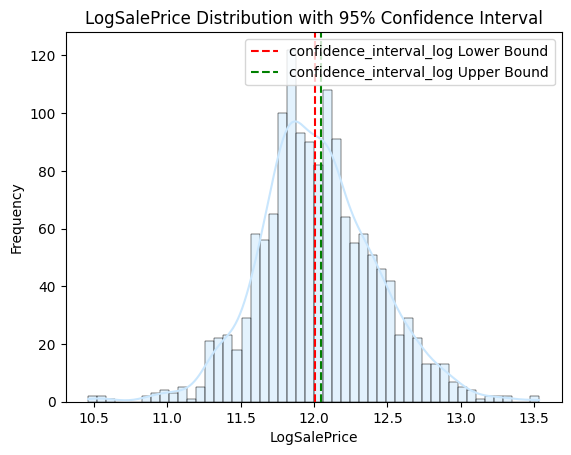

In [21]:
sns.histplot(train['LogSalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)
plt.axvline(confidence_interval_log[0], color='red', linestyle='--', label='confidence_interval_log Lower Bound')
plt.axvline(confidence_interval_log[1], color='green', linestyle='--', label='confidence_interval_log Upper Bound')
plt.title('LogSalePrice Distribution with 95% Confidence Interval')
plt.xlabel('LogSalePrice')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Hypothesis testing
 — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?

In [22]:
hypothetisis_value = 180000
hypothetisis_value_log = np.log(hypothetisis_value)
t_statistic, p_value = stats.ttest_1samp(train['LogSalePrice'], popmean=hypothetisis_value_log, nan_policy='omit')
print(f"T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")

T-statistic: -7.333, P-value: 0.000


In [23]:
shapiro_stat, shapiro_p = stats.shapiro(train['LogSalePrice'].dropna())
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.3f}, P-value={shapiro_p:.3f}")

Shapiro-Wilk Test: Statistic=0.991, P-value=0.000


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_85512/1960538830.py:12: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_85512/1960538830.py:12: SyntaxWarning: invalid escape sequence '\s'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')


Skewness after log transformation: 0.121


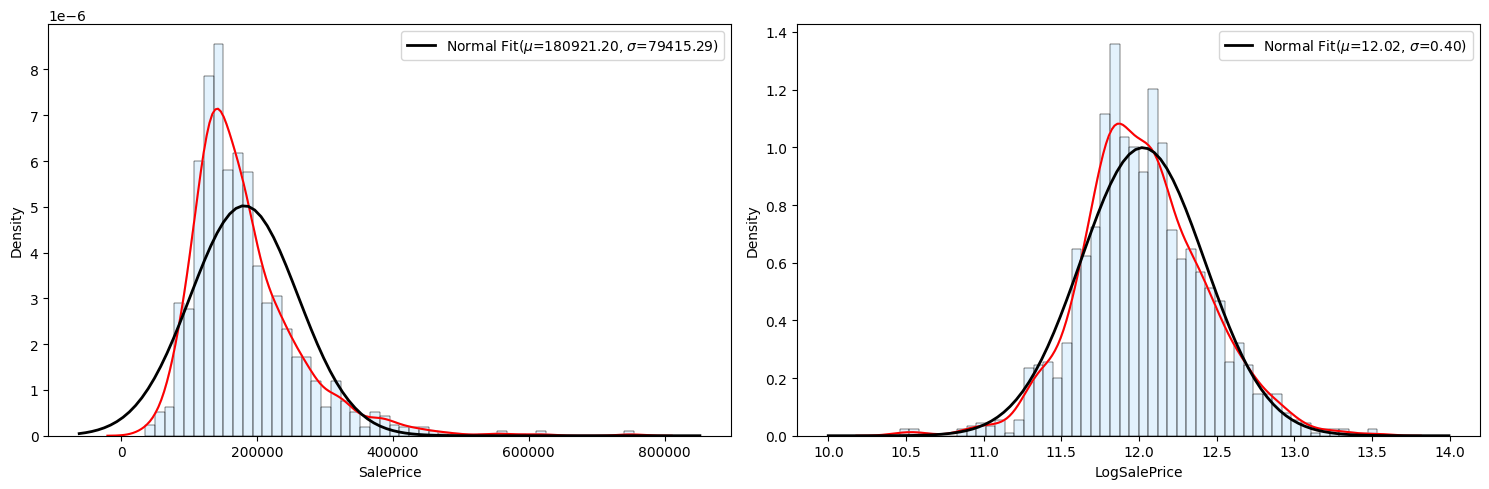

In [24]:
print(f'Skewness after log transformation: {train["LogSalePrice"].skew():.3f}')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols = ['SalePrice', 'LogSalePrice']
for i, col in enumerate(cols):
    sns.histplot(train[col], bins=50, ax=axes[i],
                stat='density', kde=True, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    sns.kdeplot(train[col], ax=axes[i], color='red', linewidth=1.5)
    mu, std = stats.norm.fit(train[col])
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    axes[i].legend()
plt.tight_layout()
plt.show()

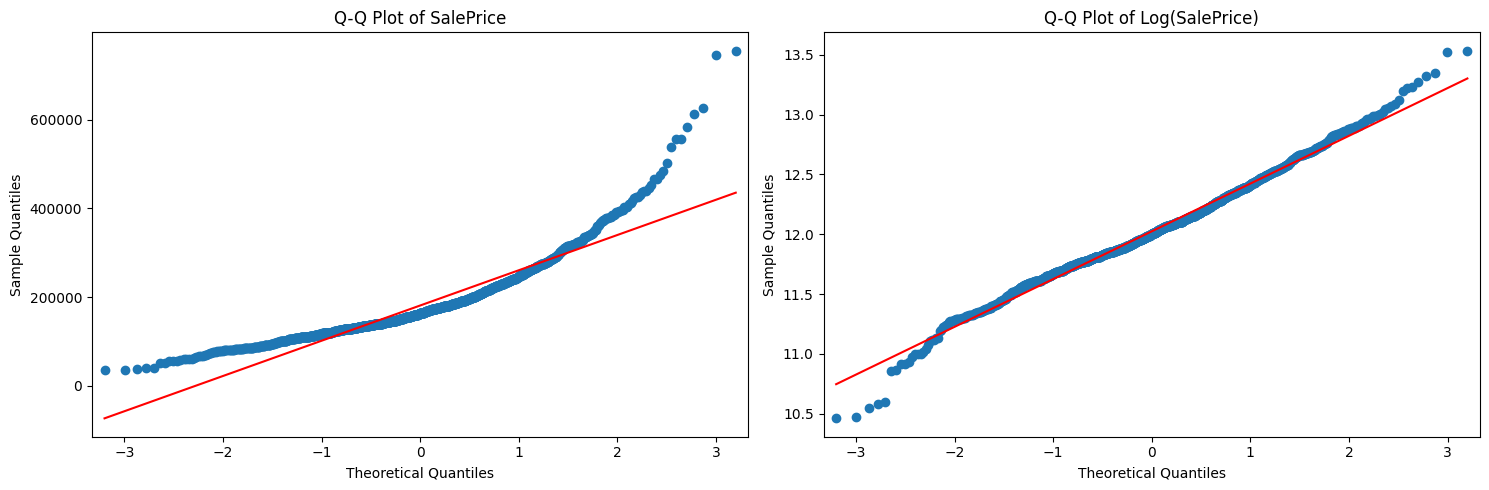

In [25]:
#Q-Q plot for SalePrice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sm.qqplot(train['SalePrice'], line='s', ax=axes[0])
sm.qqplot(train['LogSalePrice'], line='s', ax=axes[1])
axes[0].set_title('Q-Q Plot of SalePrice')
axes[1].set_title('Q-Q Plot of Log(SalePrice)')

plt.tight_layout()
plt.show()

In [26]:
#Shapiro-Wilk test for SalePrice
shapiro_test = stats.shapiro(train['LogSalePrice'])
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

Shapiro-Wilk test statistic: 0.991, p-value: 1.149e-07


The Q-Q plots and Shapiro-Wilk test ($H_0$: normal distribution) confirm that the log transformation of SalePrice yields an approximately normal distribution (p-value < 0.05).

## Missing Values

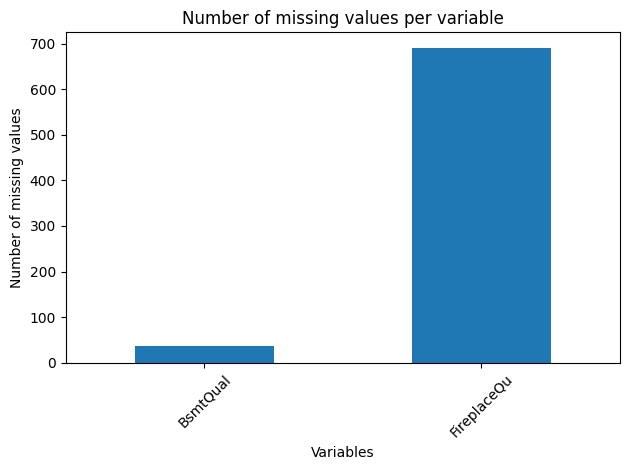

In [27]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_null = train[features]
missing_pd = train_null.isnull()
missing = missing_pd.sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
plt.title('Number of missing values per variable')
plt.ylabel('Number of missing values')
plt.xlabel('Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
#sns.histplot(train_null['OverallQual'], kde=False)
train[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OverallQual  1460 non-null   int64  
 1   ExterQual    1460 non-null   int64  
 2   BsmtQual     1423 non-null   float64
 3   KitchenQual  1460 non-null   int64  
 4   FireplaceQu  770 non-null    float64
 5   CentralAir   1460 non-null   int64  
 6   LotShape     1460 non-null   int64  
 7   LandSlope    1460 non-null   int64  
 8   MoSold       1460 non-null   int64  
 9   YrSold       1460 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 114.2 KB


## Analysis of TotalBsmtSF

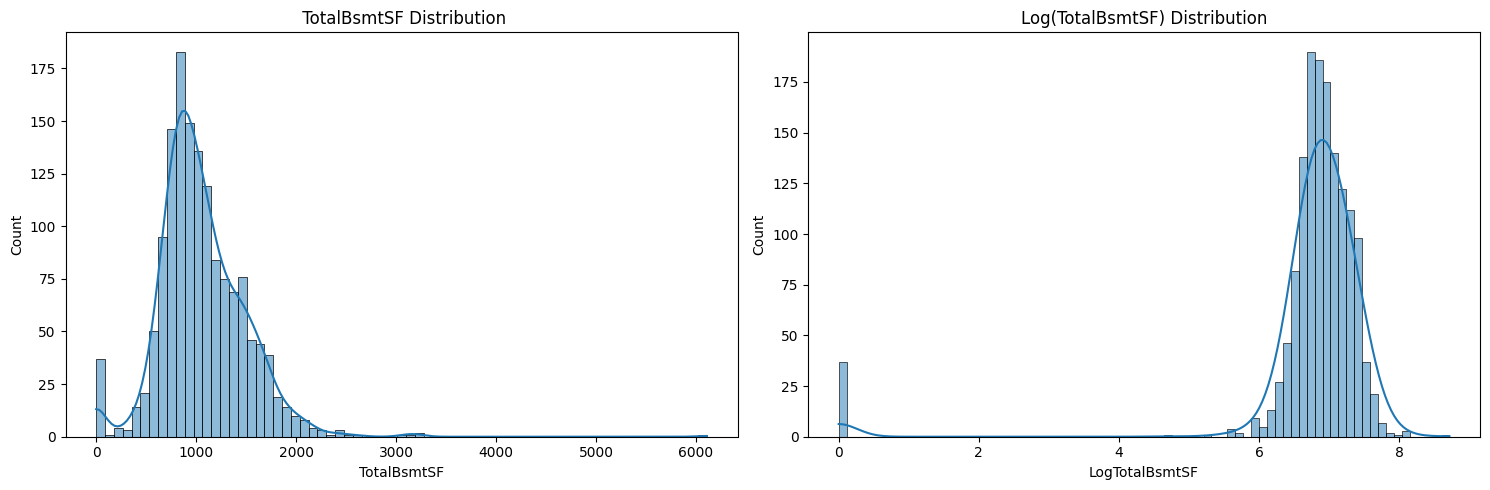

In [29]:
train['TotalBsmtSF']
train['LogTotalBsmtSF'] = np.log1p(train['TotalBsmtSF'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title(' TotalBsmtSF Distribution')
sns.histplot(train['TotalBsmtSF'], kde=True, ax=axes[0])
axes[1].set_title('Log(TotalBsmtSF) Distribution')
sns.histplot(train['LogTotalBsmtSF'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [30]:
TotalBsmtSF_skew = train['TotalBsmtSF'].skew()
LogTotalBsmtSF_skew = train['LogTotalBsmtSF'].skew()
print(f'Skewness of TotalBsmtSF: {TotalBsmtSF_skew:.3f}')
print(f'Skewness of Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')

Skewness of TotalBsmtSF: 1.524
Skewness of Log(TotalBsmtSF): -5.155


In [31]:
LogGrLivArea = np.log(train['GrLivArea'])
LogTotalBsmtSF = np.log1p(train['TotalBsmtSF'])
LogTotalBsmtSF_skew = LogTotalBsmtSF.skew()
LogGrLivArea_skew = LogGrLivArea.skew()
print(f'Skewness of Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')
print(f'Skewness of Log(GrLivArea): {LogGrLivArea_skew:.3f}')

Skewness of Log(TotalBsmtSF): -5.155
Skewness of Log(GrLivArea): -0.007


Skewness of Log(TotalBsmtSF): -5.155


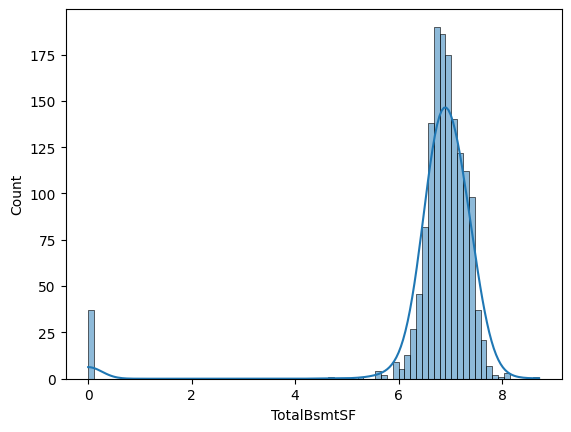

In [32]:
sns.histplot(LogTotalBsmtSF, kde=True)
LogTotalBsmtSF_skew=LogTotalBsmtSF.skew()
print(f'Skewness of Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')

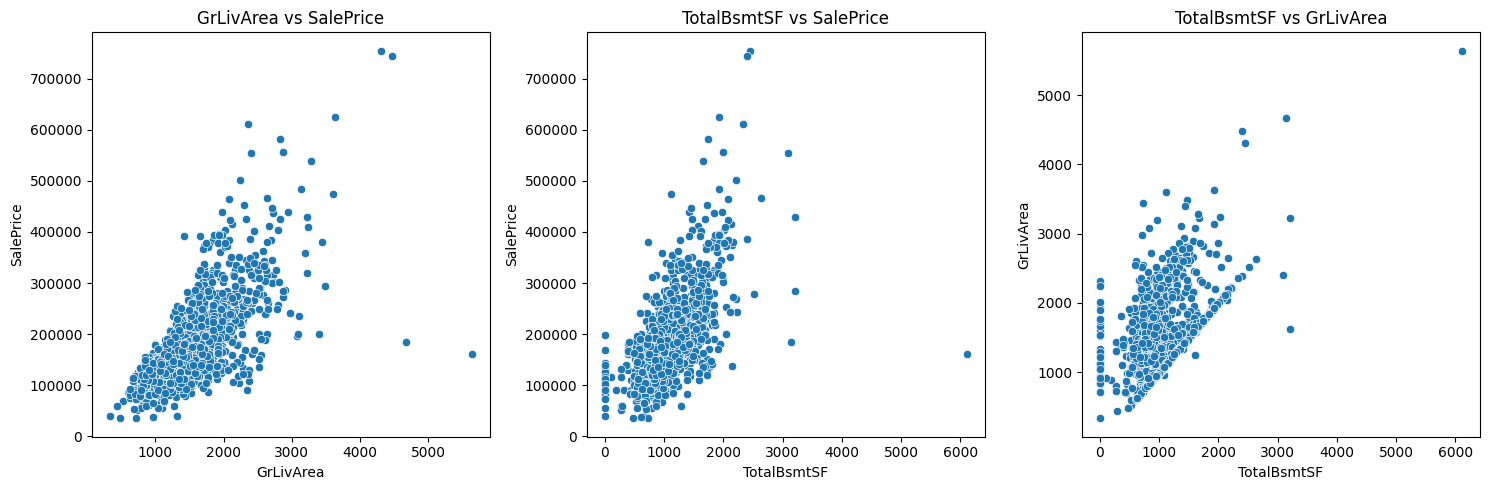

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('TotalBsmtSF vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='GrLivArea', data=train, ax=axes[2])
axes[2].set_title('TotalBsmtSF vs GrLivArea')
plt.tight_layout()

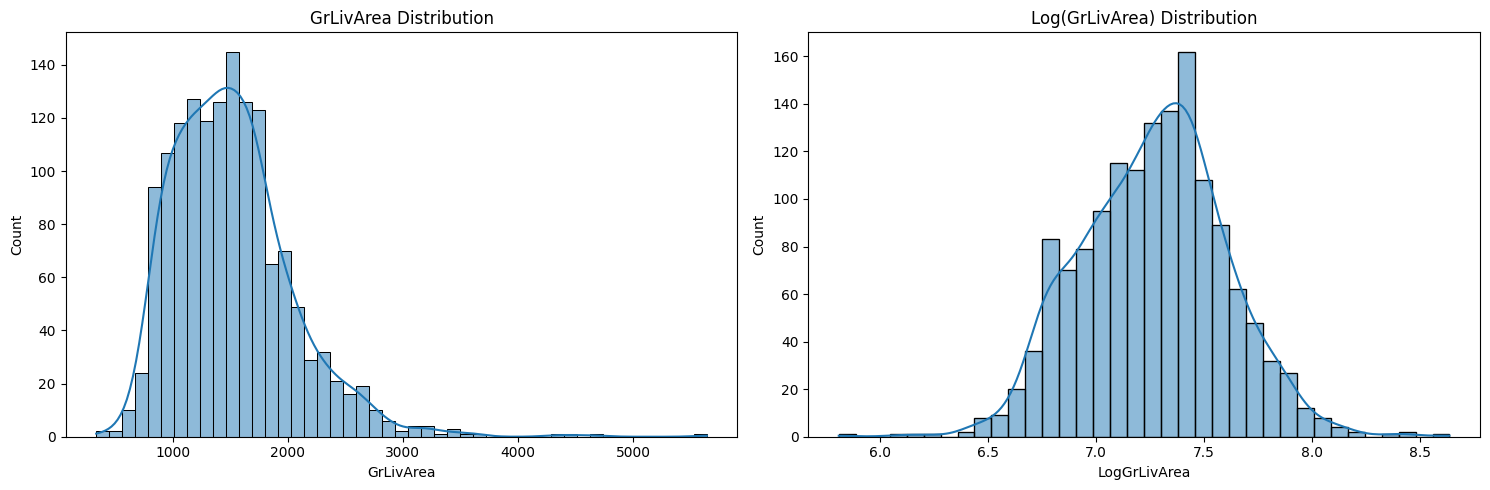

In [34]:
train['LogGrLivArea'] = np.log(train['GrLivArea'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('GrLivArea Distribution')
sns.histplot(train['GrLivArea'], kde=True, ax=axes[0])
axes[1].set_title('Log(GrLivArea) Distribution')
sns.histplot(train['LogGrLivArea'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [35]:
# CI for the mean SalePrice (95%)
alpha = 0.05
mean = np.mean(train['SalePrice'])               # Mean
s = np.std(train['SalePrice'], ddof = 1)         # Standard deviation
se = s/np.sqrt(n)                                # Standard error
t_critical_value = stats.t.ppf(1-alpha/2, df=n - 1)  # (two-tailed)
low_bound = mean - t_critical_value * se         # Lower bound
up_bound = mean + t_critical_value * se          # Upper bound

print(f"Mean: {mean:,.2f}")
print(f"CI: [{low_bound:,.2f}, {up_bound:,.2f}]")

Mean: 180,921.20
CI: [176,842.84, 184,999.55]


In [36]:
# Hypothesis testing: is the mean SalePrice significantly different from $180,000?
mu0 = 180000
dof = n - 1
T = (mean - mu0) / se
p_value = 2 * (1 - stats.t.cdf(abs(T), df=dof))

print(f"T statistic: {T}")
print(f"p-value: {p_value}")

print(p_value < alpha)

T statistic: 0.44307321990459303
p-value: 0.6577784607522805
False


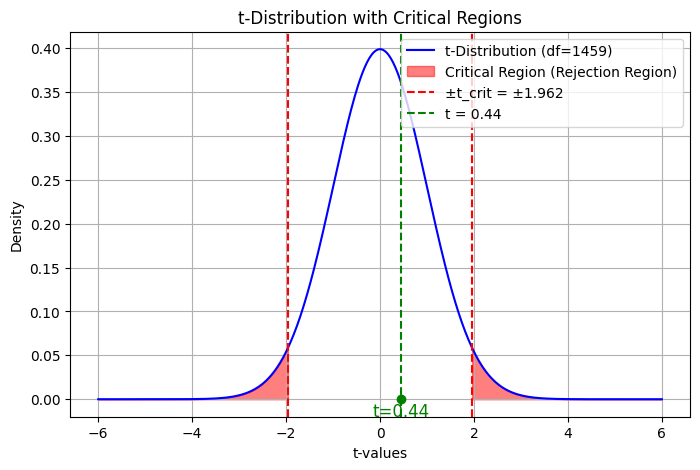

In [37]:
x = np.linspace(-6, 6, 500)
y = stats.t.pdf(x, dof)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"t-Distribution (df={dof})", color="blue")

# critical region (two-tailed test)
x_critical_left = np.linspace(-6, -t_critical_value, 300)
x_critical_right = np.linspace(t_critical_value, 6, 300)
plt.fill_between(x_critical_left, stats.t.pdf(x_critical_left, dof), color='red', alpha=0.5, label='Critical Region (Rejection Region)')
plt.fill_between(x_critical_right, stats.t.pdf(x_critical_right, dof), color='red', alpha=0.5)

plt.axvline(-t_critical_value, color="red", linestyle="--", label=f"±t_crit = ±{t_critical_value:.3f}")
plt.axvline(t_critical_value, color="red", linestyle="--")

plt.axvline(T, color='green', linestyle='--', label=f't = {round(T,2)}')
plt.scatter([T], [0], color='green', zorder=3)  # Mark the t-value on the x-axis
plt.text(T, -0.02, f't={round(T,2)}', color='green', fontsize=12, ha='center')

plt.title('t-Distribution with Critical Regions')
plt.xlabel('t-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

## One-Way ANOVA

In [38]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_anova = train[features + ['LogSalePrice']].copy()
for col in features:
    train_anova[col] = train_anova[col].fillna('None').astype('category')
anova_results = []
for col in features:
    model = ols(f'LogSalePrice ~ C({col})', data=train_anova).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]
    anova_results.append({'Feature': col, 'p-value': p_value, 'Significant': p_value < 0.05})
df_anova = pd.DataFrame(anova_results)
print(df_anova.sort_values(by='p-value'))


       Feature        p-value  Significant
0  OverallQual   0.000000e+00         True
1    ExterQual  6.935425e-195         True
2     BsmtQual  2.031282e-188         True
3  KitchenQual  4.441486e-187         True
4  FireplaceQu  6.963458e-115         True
5   CentralAir   9.855628e-44         True
6     LotShape   7.856968e-29         True
7    LandSlope   3.388375e-01        False
8       MoSold   4.496616e-01        False
9       YrSold   5.656374e-01        False


/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_85512/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_85512/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_85512/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

## Two-Way ANOVA

In [39]:
from itertools import combinations
for col1, col2 in combinations(features, 2):
    formula = f'LogSalePrice ~ C({col1}) * C({col2})'
    interaction_model = ols(formula, data=train_anova).fit()
    interaction_table = sm.stats.anova_lm(interaction_model, typ=2)
    p_value_interaction = interaction_table.iloc[2,3]
    if p_value_interaction < 0.05:
        print(f"\n--- Significant interaction between {col1} and {col2} ---")
        print(f"   Interaction p-value: {p_value_interaction:.3e}")
        print(interaction_table)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 21
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 


--- Significant interaction between OverallQual and ExterQual ---
   Interaction p-value: 5.296e-52
                                 sum_sq      df           F         PR(>F)
C(OverallQual)               204.185376     9.0  458.077839  6.178398e-294
C(ExterQual)                   0.218335     3.0    1.469465   2.210927e-01
C(OverallQual):C(ExterQual)   21.397849    27.0   16.001604   5.296425e-52
Residual                      70.922798  1432.0         NaN            NaN

--- Significant interaction between OverallQual and BsmtQual ---
   Interaction p-value: 3.482e-82
                                  sum_sq      df             F         PR(>F)
C(OverallQual)              1.014226e+02     9.0  2.317303e+02  2.612629e-181
C(BsmtQual)                 1.999443e-10     4.0  1.027874e-09   9.999744e-01
C(OverallQual):C(BsmtQual)  3.794745e+01    36.0  2.167558e+01   3.482239e-82
Residual                    6.944446e+01  1428.0           NaN            NaN

--- Significant interaction betwe

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 13
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 

## Tukey HSD Post-Hoc Test


--- Tukey HSD for OverallQual ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9819    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0  0.6541  1.683   True
     1      7    1.423    0.0  0.9083 1.9377   True
     1      8   1.6984    0.0  1.1823 2.2145   True
     1      9   1.9945    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3075 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2492 2.0945   True
     2      9   1.9679    0.0

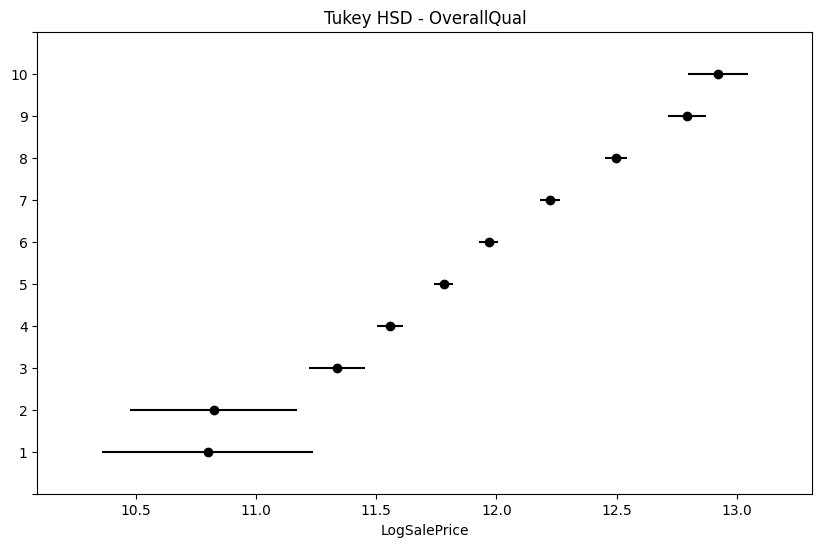


--- Tukey HSD for ExterQual ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     2      3   0.5334   0.0 0.3301 0.7368   True
     2      4   1.0067   0.0 0.8021 1.2114   True
     2      5   1.4595   0.0 1.2322 1.6868   True
     3      4   0.4733   0.0 0.4309 0.5157   True
     3      5   0.9261   0.0 0.8184 1.0337   True
     4      5   0.4528   0.0 0.3426 0.5629   True
-------------------------------------------------


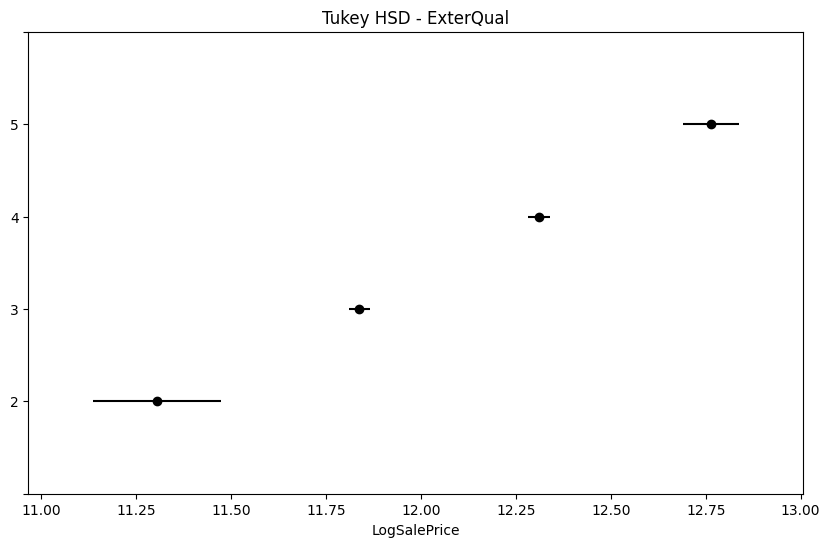

TypeError: '<' not supported between instances of 'str' and 'float'

In [40]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
for col in features:
    tukey = pairwise_tukeyhsd(endog=train_anova['LogSalePrice'], groups=train_anova[col], alpha=0.05)
    print(f"\n--- Tukey HSD for {col} ---")
    print(tukey.summary())
    tukey.plot_simultaneous()
    plt.title(f'Tukey HSD - {col}')
    plt.xlabel('LogSalePrice')
    plt.show()

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [41]:
# Factors:
# A: OverallQual -> High (≥7) = +1, Low (<7) = -1
# B: KitchenQual -> High (Ex/Gd) = +1, Low (TA/Fa/Po) = -1
# C: CentralAir  -> Yes = +1, No = -1

# Number of factors
k = 3 

df_factorial = train[['LogSalePrice']].copy()
df_factorial['A'] = np.where(train['OverallQual'] >= 7, 1, -1)
df_factorial['B'] = np.where(train['KitchenQual'].isin(['Ex', 'Gd']), 1, -1)
df_factorial['C'] = np.where(train['CentralAir'] == 'Y', 1, -1)

# Number of total observations
N = len(df_factorial)
print(f"N = {N}")

N = 1460


In [42]:
# Group Means
def group_mean(a, b, c):
    mask = (df_factorial['A'] == a) & (df_factorial['B'] == b) & (df_factorial['C'] == c)
    return df_factorial.loc[mask, 'LogSalePrice'].mean()

treatment_comb_1 = group_mean(-1, -1, -1)
a_val = group_mean(-1, -1, -1)
b_val = group_mean(-1, 1, -1)
ab_val = group_mean(1, 1, -1)
c_val = group_mean(-1, -1, 1)
ac_val = group_mean(1, -1, 1)
bc_val = group_mean(-1, 1, 1)
abc_val = group_mean(1, 1, 1)

means_table = pd.DataFrame({
    'A': [-1, 1, -1, 1, -1, 1, -1, 1],
    'B': [-1, -1, 1, 1, -1, -1, 1, 1],
    'C': [-1, -1, -1, -1, 1, 1, 1, 1],
    'Mean LogSalePrice': [treatment_comb_1, a_val, b_val, ab_val, c_val, ac_val, bc_val, abc_val]
})

print("Group means for all 2^3 combinations:")
print(means_table)

Group means for all 2^3 combinations:
   A  B  C  Mean LogSalePrice
0 -1 -1 -1          11.813757
1  1 -1 -1          11.813757
2 -1  1 -1                NaN
3  1  1 -1                NaN
4 -1 -1  1                NaN
5  1 -1  1                NaN
6 -1  1  1                NaN
7  1  1  1                NaN


In [43]:
# Factor Effects
q_A = (1 / (2**k)) * (a_val +  ab_val + ac_val + abc_val - treatment_comb_1 - b_val - c_val - bc_val)
q_B = (1 / (2**k)) * (b_val + ab_val + bc_val + abc_val - treatment_comb_1 - a_val - c_val - ac_val)
q_C = (1 / (2**k)) * (c_val + ac_val + bc_val + abc_val - treatment_comb_1 - a_val - b_val - ab_val)
q_AB = (1 / (2**k)) * (ab_val + abc_val + treatment_comb_1 - a_val - b_val + c_val - ac_val - bc_val)
q_AC = (1 / (2**k)) * (treatment_comb_1 - a_val + b_val - ab_val + abc_val  - c_val + ac_val - bc_val)
q_BC = (1 / (2**k)) * (treatment_comb_1 + a_val - b_val - ab_val - c_val - ac_val + bc_val + abc_val)
q_ABC = (1 / (2**k)) * (abc_val - bc_val - ac_val + c_val - ab_val + b_val + a_val  - treatment_comb_1)

print("Factor Effects:")
print(f"q_A (OverallQual):                  {q_A:.4f}")
print(f"q_B (KitchenQual):                  {q_B:.4f}")
print(f"q_C (CentralAir):                   {q_C:.4f}")
print(f"q_AB (OverallQual and KitchenQual): {q_AB:.4f}")
print(f"q_AC (OverallQual and CentralAir):  {q_AC:.4f}")
print(f"q_BC (KitchenQual and CentralAir):  {q_BC:.4f}")
print(f"q_ABC (three factors):              {q_ABC:.4f}")


Factor Effects:
q_A (OverallQual):                  nan
q_B (KitchenQual):                  nan
q_C (CentralAir):                   nan
q_AB (OverallQual and KitchenQual): nan
q_AC (OverallQual and CentralAir):  nan
q_BC (KitchenQual and CentralAir):  nan
q_ABC (three factors):              nan


In [44]:
df_factorial.groupby(['A','B','C']).size()

A   B   C 
-1  -1  -1    912
 1  -1  -1    548
dtype: int64

We can see that in each of the 8 groups we have a different number of houses, it's very unbalanced ranging from 3 to 618 houses per group. So we'll use an approximation, we'll take the average group size for our replicate.

In [45]:
r_avg = N / (2**k)
r_avg

182.5

In [46]:
# Sum of Squares
SS_A = (2**k) * r_avg * q_A ** 2
SS_B = (2**k) * r_avg * q_B ** 2
SS_C = (2**k) * r_avg * q_C ** 2
SS_AB = (2**k) * r_avg * q_AB ** 2
SS_AC = (2**k) * r_avg * q_AC ** 2
SS_BC = (2**k) * r_avg * q_BC ** 2
SS_ABC = (2**k) * r_avg * q_ABC ** 2

SS_M = SS_A + SS_B + SS_C + SS_AB + SS_AC + SS_BC + SS_ABC

# overall mean and total sum of squares (SST)
q_0 = df_factorial["LogSalePrice"].mean()
SST = ((df_factorial["LogSalePrice"] - q_0)**2).sum()
SSE = SST - SS_M

print("Sum of Squares:")
for name, value in [('A', SS_A), ('B', SS_B), ('C', SS_C), ('AB', SS_AB), 
                    ('AC', SS_AC), ('BC', SS_BC), ('ABC', SS_ABC)]:
    print(f"SS_{name} = {value:.4f}")

print(f"\nModel Sum of Squares (SS_M) = {SS_M:.4f}")
print(f"Total Sum of Squares (SST)  = {SST:.4f}")
print(f"Sum of Squared Errors (SSE) = {SSE:.4f}")

Sum of Squares:
SS_A = nan
SS_B = nan
SS_C = nan
SS_AB = nan
SS_AC = nan
SS_BC = nan
SS_ABC = nan

Model Sum of Squares (SS_M) = nan
Total Sum of Squares (SST)  = 232.8007
Sum of Squared Errors (SSE) = nan


In [47]:
# Degrees of freedom and Mean Squareds
df_A = df_B = df_C = df_AB = df_AC = df_BC = df_ABC = 1
df_M = 7
df_T = N - 1
df_E = df_T - df_M

MS_A = SS_A / df_A
MS_B = SS_B / df_B
MS_C = SS_C / df_C
MS_AB = SS_AB / df_AB
MS_AC = SS_AC / df_AC
MS_BC = SS_BC / df_BC
MS_ABC = SS_ABC / df_ABC
MSE = SSE / df_E

print("Mean Squares:")
for name, value in [('A', MS_A), ('B', MS_B), ('C', MS_C), ('AB', MS_AB), 
                    ('AC', MS_AC), ('BC', MS_BC), ('ABC', MS_ABC), ('E', MSE)]:
    print(f"MS_{name} = {value:.4f}")

Mean Squares:
MS_A = nan
MS_B = nan
MS_C = nan
MS_AB = nan
MS_AC = nan
MS_BC = nan
MS_ABC = nan
MS_E = nan


In [48]:
# F-statistics and p-value
F_A = MS_A / MSE
F_B = MS_B / MSE
F_C = MS_C / MSE
F_AB = MS_AB / MSE
F_AC = MS_AC / MSE
F_BC = MS_BC / MSE
F_ABC = MS_ABC / MSE



p_A = 1 - stats.f.cdf(F_A, df_A, df_E)
p_B = 1 - stats.f.cdf(F_B, df_B, df_E)
p_C = 1 - stats.f.cdf(F_C, df_C, df_E)
p_AB = 1 - stats.f.cdf(F_AB, df_AB, df_E)
p_AC = 1 - stats.f.cdf(F_AC, df_AC, df_E)
p_BC = 1 - stats.f.cdf(F_BC, df_BC, df_E)
p_ABC = 1 - stats.f.cdf(F_ABC, df_ABC, df_E)

print(f"{'Effect':<8} {'F-stat':>10} {'p-value':>12} {'Significant':>12}")
for name, F, p in [('A', F_A, p_A), ('B', F_B, p_B), ('C', F_C, p_C), ('AB', F_AB, p_AB), 
                   ('AC', F_AC, p_AC), ('BC', F_BC, p_BC), ('ABC', F_ABC, p_ABC)]:
    print(f"{name:<8} {F:>10.2f} {p:>12.6f} {'True' if p < 0.05 else 'False':>12}")

Effect       F-stat      p-value  Significant
A               nan          nan        False
B               nan          nan        False
C               nan          nan        False
AB              nan          nan        False
AC              nan          nan        False
BC              nan          nan        False
ABC             nan          nan        False


### Balanced Dataset Constraint

The classical $2^k$ factorial designs have a strict requirement for a perfectly balanced dataset, meaning that there are an equal number of observations (replicates) for every unique combination of factor levels.

In our dataset however, group sizes range from 3 to 618 houses which is far from balanced. Using $\text{r\_avg} = N/2^k = 182.5$ as an approximation, it inflates all SS values, resulting in a very small MSE (0.05) and extremely large F-statistics (600-1200), making every effect appear significant.

To address this, we use OLS regression which correctly handles unbalanced groups.

## Analysis using OLS

In [49]:
df_factorial['AB'] = df_factorial['A'] * df_factorial['B']
df_factorial['AC'] = df_factorial['A'] * df_factorial['C']
df_factorial['BC'] = df_factorial['B'] * df_factorial['C']
df_factorial['ABC'] = df_factorial['A'] * df_factorial['B'] * df_factorial['C']

model = ols('LogSalePrice ~ A + B + C + AB + AC + BC + ABC', data=df_factorial).fit()

anova_table_2k = sm.stats.anova_lm(model, typ=2)
print(anova_table_2k)

                 sum_sq      df             F         PR(>F)
A            107.453137     1.0  1.249859e+03  3.036843e-198
B         200269.480237     1.0  2.329467e+06   0.000000e+00
C         200269.480237     1.0  2.329467e+06   0.000000e+00
AB           107.453137     1.0  1.249859e+03  3.036843e-198
AC           107.453137     1.0  1.249859e+03  3.036843e-198
BC        200269.480237     1.0  2.329467e+06   0.000000e+00
ABC          107.453137     1.0  1.249859e+03  3.036843e-198
Residual     125.347522  1458.0           NaN            NaN


In [50]:
# Extract SS and MSE from OLS table
SS_A = anova_table_2k.loc['A', 'sum_sq']
SS_B = anova_table_2k.loc['B', 'sum_sq']
SS_C = anova_table_2k.loc['C', 'sum_sq']
SS_AB = anova_table_2k.loc['AB', 'sum_sq']
SS_AC = anova_table_2k.loc['AC', 'sum_sq']
SS_BC = anova_table_2k.loc['BC', 'sum_sq']
SS_ABC = anova_table_2k.loc['ABC', 'sum_sq']
SSE = anova_table_2k.loc['Residual', 'sum_sq']
df_E = anova_table_2k.loc['Residual', 'df']
MSE = SSE / df_E

SS_M_ols= SS_A + SS_B + SS_C + SS_AB + SS_AC + SS_BC + SS_ABC
SST_ols = SS_M_ols + SSE

In [51]:
# Main Effects
SS_Main_Effects = SS_A + SS_B + SS_C
df_Main_Effects = 3
MS_Main_Effects = SS_Main_Effects / df_Main_Effects
F_Main_Effects = MS_Main_Effects / MSE
p_Main_Effects = 1 - stats.f.cdf(F_Main_Effects, df_Main_Effects, df_E)

print("Main Effects:")
print(f"SS      : {SS_Main_Effects}")
print(f"MS      : {MS_Main_Effects}")
print(f"F       : {F_Main_Effects}")
print(f"p-value : {p_Main_Effects}")

Main Effects:
SS      : 400646.41360955697
MS      : 133548.804536519
F       : 1553394.5400414306
p-value : 0.0


In [52]:
# Two-Way Interaction Effects 
SS_Two_Way = SS_AB + SS_AC + SS_BC
df_Two_Way = 3
MS_Two_Way = SS_Two_Way / df_Two_Way
F_Two_Way = MS_Two_Way / MSE
p_Two_Way = 1 - stats.f.cdf(F_Two_Way, df_Two_Way, df_E)

print("Two-Way Interactions Effects:")
print(f"SS      : {SS_Two_Way}")
print(f"MS      : {MS_Two_Way}")
print(f"F       : {F_Two_Way}")
print(f"p-value : {p_Two_Way}")

Two-Way Interactions Effects:
SS      : 200484.3865095549
MS      : 66828.1288365183
F       : 777322.199297155
p-value : 0.0


In [53]:
# Three-Way Interaction Effects 
SS_Three_Way = SS_ABC
df_Three_Way = 1
MS_Three_Way = SS_Three_Way / df_Three_Way
F_Three_Way = MS_Three_Way / MSE
p_Three_Way = 1 - stats.f.cdf(F_Three_Way, df_Three_Way, df_E)

print(f"SS      : {SS_Three_Way}")
print(f"MS      : {MS_Three_Way}")
print(f"F       : {F_Three_Way}")
print(f"p-value : {p_Three_Way}")

SS      : 107.45313651760503
MS      : 107.45313651760503
F       : 1249.8585528793
p-value : 0.0


In [54]:
# Model F-statistics and R^2
df_model = 7
df_T_ols = int(df_E) + df_model

MS_M = SS_M_ols / df_model
F_M = MS_M / MSE

R_square = SS_M_ols / SST_ols
R_square_adj = 1 - ((SSE / df_E) / (SST_ols / df_T_ols))

print("Model Statistics:")
print(f"MS_M    = {MS_M}")
print(f"F_M     = {F_M}")
print(f"R^2     = {R_square}")
print(f"R^2_adj = {R_square_adj}")

Model Statistics:
MS_M    = 85891.17903651849
F_M     = 999057.1537955194
R^2     = 0.9997915611747886
R^2_adj = 0.9997905604396882


In [55]:
# TO DO: Visualisations

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.

In [69]:
train_anova = train.copy()
test_anova = test.copy()
train_anova['LogSalePrice'] = np.log1p(train_anova['SalePrice'])

In [70]:
nouvelles_colonnes = ['LogGrLivArea', 'LogTotalBsmtSF']
for df in [train_anova, test_anova]:
    if not all(col in df.columns for col in nouvelles_colonnes):
        df['LogGrLivArea'] = np.log(df['GrLivArea'])
        df['LogTotalBsmtSF'] = np.log1p(df['TotalBsmtSF'])

In [71]:
train_anova['LotFrontage'].unique()
train_anova['BsmtQual'].unique()
train_anova['LotFrontage'] = train_anova['LotFrontage'].fillna(0)
train_anova['GarageYrBlt'] = train_anova['GarageYrBlt'].fillna(0)
train_anova['MasVnrArea'] = train_anova['MasVnrArea'].fillna(0)
manquants = train_anova.isna().sum()
print("Nombre de valeurs manquantes par colonne :")
print(manquants[manquants > 0])

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


Nombre de valeurs manquantes par colonne :
Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [73]:
def accuracy_model(model, data_X, data_y, pct_close = 0.1):
    n_correct = 0; n_wrong = 0
    predicted = model.predict(data_X)
    for i in range(len(predicted)):
        actual = data_y[i]
        pred = predicted[i]
        if np.abs(pred - actual) < np.abs(pct_close * actual):
            n_correct += 1
        else:
            n_wrong += 1
    accuracy = (n_correct * 1.0) / (n_correct + n_wrong)
    return accuracy
def accuracy_model_q(model, data_X, data_y, pct_close = 0.1):
    n_itmes = len(data_y)
    pred = model.predict(data_X)
    np_correct = np.sum(np.abs(pred - data_y) < np.abs(pct_close * data_y))
    result = (np_correct * 1.0) / n_itmes
    return result
def main3(train_anova,variable_y = 'LogSalePrice', min_layer_input=1, min_layer_output=1, max_layer_input=None, max_layer_output=None, learning_rate=0.01, max_iter=500):
    if not max_layer_input:
        max_layer_input = 100
    if not max_layer_output:
        max_layer_output = 50
    result = {}
    print("\nLoad data ")
    train = train_anova
    X = train_anova.drop(columns=[variable_y])
    Y = train_anova[variable_y].to_numpy()
    polynomial_features = ['LogTotalBsmtSF', 'LogGrLivArea']
    nums_colums = [col for col in X.columns if col not in polynomial_features and X[col].dtype in ['int64', 'float64']]
    #nums_colums = X.select_dtypes(include=['number']).columns.tolist()
    cat_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
    polynomial_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler())
        ])
    num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor_template = ColumnTransformer(
        transformers=[
            ('num', num_pipeline, nums_colums),
            ('poly', polynomial_pipeline, polynomial_features),
            ('cat', cat_pipeline, cat_columns)
        ])
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


   

    for j in range(max_layer_output, min_layer_output, -1):
        result[j] = {'inputs': [], 'rmse': [], 'r2': []} 
        for i in range(max_layer_input, min_layer_input, -1):
            mlp = MLPRegressor(hidden_layer_sizes=(i, j),
                    activation='relu', 
                    solver='adam', alpha=0.001,
                    learning_rate_init = learning_rate,
                    shuffle=True, random_state=42,
                    max_iter=max_iter)
            model_pipeline = Pipeline(
                steps=[
                    ('preprocessor', clone(preprocessor_template)),
                    ('regressor', mlp)])
            
            model_pipeline.fit(x_train, y_train)
            y_pred = model_pipeline.predict(x_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            result[j]['inputs'].append(i)
            result[j]['rmse'].append(rmse)
            result[j]['r2'].append(r2)
    print("\nResults for RMSE:")
    for j in result.keys():
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        axes[0].plot(result[j]['inputs'], result[j]['rmse'], marker='o')
        axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        axes[0].set_title(f'RMSE for  Layer output = {j}')
        axes[0].set_ylabel('RMSE')
        axes[0].set_xlabel('Max Layer input')
        axes[0].grid()
        axes[1].plot(result[j]['inputs'], result[j]['r2'], marker='o')
        axes[1].set_title(f'R2 Score for  Layer output = {j}')
        axes[1].set_ylabel('R2 Score')
        axes[1].set_xlabel('Max Layer input')
        axes[1].grid()
        plt.tight_layout()
        plt.show()




    

In [ ]:
main3(train_anova , variable_y='LogSalePrice', min_layer_input=50, min_layer_output=50, max_layer_input=560, max_layer_output=60, learning_rate=0.0001, max_iter=1500)


Load data 


In [ ]:
def accuracy_model(model, data_X, data_y, pct_close = 0.1):
    n_correct = 0; n_wrong = 0
    predicted = model.predict(data_X)
    for i in range(len(predicted)):
        actual = data_y[i]
        pred = predicted[i]
        if np.abs(pred - actual) < np.abs(pct_close * actual):
            n_correct += 1
        else:
            n_wrong += 1
    accuracy = (n_correct * 1.0) / (n_correct + n_wrong)
    return accuracy
def accuracy_model_q(model, data_X, data_y, pct_close = 0.1):
    n_itmes = len(data_y)
    pred = model.predict(data_X)
    np_correct = np.sum(np.abs(pred - data_y) < np.abs(pct_close * data_y))
    result = (np_correct * 1.0) / n_itmes
    return result
def main_4(train_anova,variable_y = 'LogSalePrice', layer_input=56, layer_output=56, learning_rate=0.01, max_iter=500):

    print("\nLoad data ")
    train = train_anova
    X = train_anova.drop(columns=[variable_y])
    Y = train_anova[variable_y].to_numpy()
    nums_colums = X.select_dtypes(include=['number']).columns.tolist()
    cat_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor_template = ColumnTransformer(
        transformers=[
            ('num', num_pipeline, nums_colums),
            ('cat', cat_pipeline, cat_columns)
        ])
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    
    mlp = MLPRegressor(hidden_layer_sizes=(layer_input, layer_output),
            activation='relu', 
            solver='lbfgs', alpha=0.001,
            learning_rate_init = learning_rate,
            shuffle=True, random_state=42,
            max_iter=max_iter)
    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', clone(preprocessor_template)),
            ('regressor', mlp)])
    
    model_pipeline.fit(x_train, y_train)
    y_pred = model_pipeline.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print("\nResults for RMSE:")
    print("_"*50)
    print(f'RMSE for  Layer output = {layer_output} and Layer input = {layer_input} : {rmse:.4f}')
    print(f'R2 Score for  Layer output = {layer_output} and Layer input = {layer_input} : {r2:.4f}')
    print("_"*50)
    return model_pipeline, preprocessor_template



    

In [ ]:
main_4(train_anova , variable_y='LogSalePrice', layer_input=41, layer_output=42, learning_rate=0.001, max_iter=1500)

In [ ]:
main_4(train_anova , variable_y='LogSalePrice', layer_input=56, layer_output=56, learning_rate=0.001, max_iter=1500)

In [ ]:
X = train_anova.drop(columns=['LogSalePrice', 'Id', 'SalePrice'])
Y = train_anova['LogSalePrice'].to_numpy()
nums_colums = X.select_dtypes(include=['number']).columns.tolist()
cat_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor_template = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, nums_colums),
        ('cat', cat_pipeline, cat_columns)
    ])
best_model = MLPRegressor(hidden_layer_sizes=(51, 53),
            activation='relu',
            solver='lbfgs', alpha=0.001,
            learning_rate_init = 0.001,
            shuffle=True, random_state=42,
            max_iter=1500)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', clone(preprocessor_template)),
        ('regressor', best_model)])
model_pipeline.fit(X, Y)
X_test_kaggle = test_anova.drop(columns=['Id'])
predictions_log = model_pipeline.predict(X_test_kaggle)
predictions = np.exp(predictions_log)
submission = pd.DataFrame({
    'Id': test_anova['Id'],
    'SalePrice': predictions
})
submission.to_csv('submission.csv', index=False)